<a href="https://colab.research.google.com/github/gslrn2023/TestQR_Collab/blob/main/AI_Emotion_detector_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'transformers'...
remote: Enumerating objects: 484402, done.
remote: Counting objects: 100% (1355/1355), done.
remote: Compressing objects: 100% (610/610), done.
remote: Total 484402 (delta 1093), reused 789 (delta 738), pack-reused 483047 (from 3)
Receiving objects: 100% (484402/484402), 494.28 MiB | 15.36 MiB/s, done.
Resolving deltas: 100% (373430/373430), done.
🤖 Loading AI Model...


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  329MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Analyzed Text: 'I am super excited to try running AI models inside Google Colab today!'
---------------------------------------------
Joy         : 97.84%
Surprise    : 1.13%
Neutral     : 0.56%
Fear        : 0.15%
Anger       : 0.14%
Sadness     : 0.14%
Disgust     : 0.04%


/tmp/ipykernel_1950/3652744360.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=emotions, palette="magma")


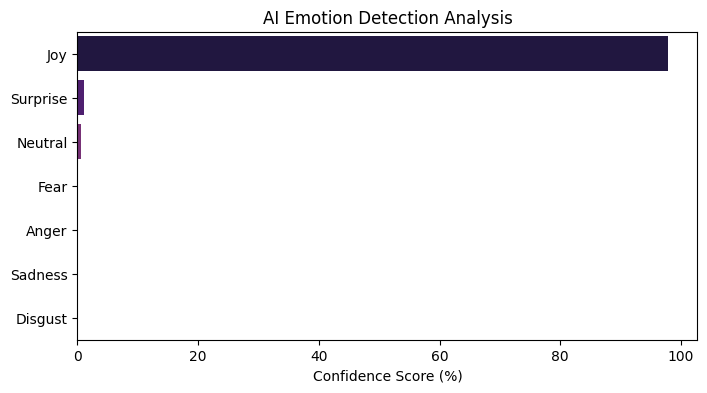

In [1]:
# 1. Clone the Hugging Face Transformers AI project repository from GitHub
!git clone https://github.com/huggingface/transformers.git

# 2. Install essential AI & Machine Learning libraries
!pip install -q transformers torch matplotlib seaborn

# 3. Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

# 4. Load a pre-trained AI NLP pipeline using top_k=None for all emotion scores
print("🤖 Loading AI Model...")
classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
)

# 5. Provide sample text and run inference
sample_text = (
    "I am super excited to try running AI models inside Google Colab today!"
)
raw_results = classifier(sample_text)

# Flatten results list if nested
results = raw_results[0] if isinstance(raw_results[0], list) else raw_results

# 6. Format results into labels and confidence scores
emotions = [item["label"].capitalize() for item in results]
scores = [item["score"] * 100 for item in results]

# Print raw AI scores
print(f"\nAnalyzed Text: '{sample_text}'")
print("-" * 45)
for emotion, score in zip(emotions, scores):
    print(f"{emotion:<12}: {score:.2f}%")

# 7. Visualize the AI output as a bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x=scores, y=emotions, palette="magma")
plt.title("AI Emotion Detection Analysis")
plt.xlabel("Confidence Score (%)")
plt.show()